# ***Assignment 8: Building a Variational Autoencoder and Visualising Its Latent Space***



###**Name:** Pragathi BR ###

###**Registration No.:** 2411021240037 ###

###**Course:** BCA (Artificial Intelligence & Machine Learning) — BCA AIML ###

###**Subject:** Generative AI ###

###**Date of Submission:** 12-09-2026 ###

###**Faculty Name**: Sanjivini Chowdhury ###

## **1. Objective**

####The objective of this assignment is to understand how a Variational Autoencoder learns a structured latent space.

####In this assignment, a Variational Autoencoder is developed using the MNIST dataset.The latent space is intentionally restricted to two dimensions so that the learned representations can be visualised on a 2D graph.

####The model is trained for approximately 20 epochs. During training, reconstruction loss and KL-divergence loss are recorded separately.

####After training, the encoder is used to convert test images into 2-dimensional latent representations. These representations are visualised using a scatter plot, with different colours representing digits from 0 to 9.

####Finally, points are selected across the latent space from approximately -3 to +3 and passed through the decoder to generate handwritten digit images.

## **2. Introduction to Variational Autoencoder**

####A Variational Autoencoder (VAE) is a generative deep learning model that learns
####how to represent data in a continuous latent space.

####A VAE consists mainly of two components:

### **Encoder**
#####The encoder takes an input image and converts it into parameters of a probability
####distribution in the latent space.

####These parameters are:

- Mean (μ)
- Log variance (log σ²)

### **Latent Space**
####The latent space contains a compact representation of the input data.

####In this assignment, the latent space has only two dimensions:

####z₁ and z₂

####This allows the latent representations to be visualised using a 2D scatter plot.

### **Decoder**
####The decoder takes a sampled latent vector and attempts to reconstruct the original
####input image.

####The decoder can also generate new images by receiving latent vectors that were not
####directly obtained from the training data.

### **Reparameterization Trick**
####Instead of directly sampling from a distribution, the VAE uses:

####z = μ + σ × ε

####where:

- μ = mean
- σ = standard deviation
- ε = random value sampled from a standard normal distribution

####This allows the model to be trained using backpropagation.

### **VAE Loss**

####The total VAE loss consists of two major components:

####Total Loss = Reconstruction Loss + KL-Divergence Loss

####Reconstruction loss measures how well the decoder reconstructs the original image.

####KL-divergence loss encourages the learned latent distribution to remain close to
####a standard normal distribution.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## **3. Loading the MNIST Dataset**

####The MNIST dataset contains handwritten grayscale images of digits from 0 to 9.

####Each image has a size of 28 × 28 pixels.

####The dataset contains:

- 60,000 training images
- 10,000 testing images
- 10 different digit
classes (0–9)

####The images are normalised to the range 0 to 1 before being given to the VAE.

In [ ]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


## **4. Data Preprocessing**

####The MNIST images are grayscale images with pixel values ranging from 0 to 255.

####For neural network training, the pixel values are scaled to the range 0 to 1.

####The 28 × 28 images are then flattened into vectors containing 784 values.

####The labels are retained separately because they will later be used to colour the
####latent-space scatter plot.

In [ ]:
# Normalize pixel values to the range 0 to 1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images from 28x28 to 784
x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

print("Processed training shape:", x_train.shape)
print("Processed testing shape:", x_test.shape)

Processed training shape: (60000, 784)
Processed testing shape: (10000, 784)


## **5. Sample MNIST Images**

####Before building the VAE, a few MNIST images are displayed to understand the input data used by the model.

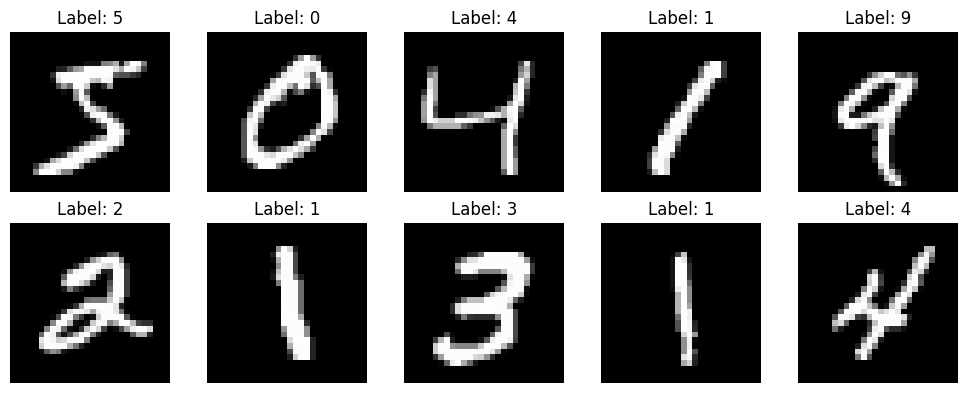

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## **6. VAE Architecture**

####The VAE used in this assignment contains an encoder, a 2-dimensional latent space, and a decoder.

####The encoder converts a 784-dimensional input image into two values representing the mean and log variance of the latent distribution.

####The latent dimension is set to 2 so that the latent space can be visualised.

####The decoder takes the 2-dimensional latent vector and reconstructs the 784-pixel MNIST image.

In [ ]:
input_dim = 784
hidden_dim = 256
latent_dim = 2

print("Input dimension:", input_dim)
print("Hidden dimension:", hidden_dim)
print("Latent dimension:", latent_dim)

Input dimension: 784
Hidden dimension: 256
Latent dimension: 2


## **7. Encoder**

####The encoder receives a flattened MNIST image containing 784 pixel values.

####A dense hidden layer is used to learn useful features from the image.

####The encoder produces two outputs:

- Mean (μ)
- Log variance (log σ²)

####These values define the probability distribution from which the latent vector is sampled.

In [ ]:
# Encoder input
encoder_inputs = layers.Input(shape=(input_dim,), name="encoder_input")

# Hidden layer
x = layers.Dense(hidden_dim, activation="relu")(encoder_inputs)

# Mean and log variance
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

print("Encoder created successfully.")

Encoder created successfully.


## **8. Reparameterization Trick**

####The VAE cannot directly backpropagate through a random sampling operation.

####Therefore, the reparameterization trick is used.

####The latent vector is calculated as:

####z = μ + exp(0.5 × log(σ²)) × ε

####where ε is sampled from a standard normal distribution.

####This separates the random component from the trainable parameters and allows gradient-based optimisation.

In [ ]:
def sampling(args):
    z_mean, z_log_var = args

    epsilon = tf.random.normal(
        shape=tf.shape(z_mean)
    )

    return z_mean + tf.exp(0.5 * z_log_var) * epsilon


z = layers.Lambda(
    sampling,
    name="z"
)([z_mean, z_log_var])

print("Reparameterization layer created.")

Reparameterization layer created.


In [ ]:
encoder = Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    200,960 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        514 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        514 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 201,988 (789.02 KB)

 Trainable params: 201,988 (789.02 KB)

 Non-trainable params: 0 (0.00 B)

## **9. Decoder**

####The decoder receives a 2-dimensional latent vector and attempts to reconstruct the original MNIST image.

####A dense layer with ReLU activation is used as the hidden layer.

####The final layer contains 784 neurons with sigmoid activation because the input pixels have values between 0 and 1.

In [ ]:
# Decoder input
latent_inputs = layers.Input(shape=(latent_dim,), name="z_sampling")

# Hidden layer
x = layers.Dense(hidden_dim, activation="relu")(latent_inputs)

# Output layer
decoder_outputs = layers.Dense(
    input_dim,
    activation="sigmoid"
)(x)

decoder = Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,256 (790.06 KB)

 Trainable params: 202,256 (790.06 KB)

 Non-trainable params: 0 (0.00 B)

## **10. Complete Variational Autoencoder**

####The complete VAE connects the encoder and decoder.

####The input image is first converted into a latent representation by the encoder.

####A latent vector is sampled using the reparameterization trick.

####The sampled latent vector is then passed to the decoder to reconstruct the image.

In [ ]:
vae_outputs = decoder(z)

vae = Model(
    encoder_inputs,
    vae_outputs,
    name="vae"
)

vae.summary()

Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    200,960 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        514 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        514 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, 784)       │    202,256 │ z[0][0]           │
│ (Functional)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 404,244 (1.54 MB)

 Trainable params: 404,244 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

## **11. VAE Loss Function**

####The VAE is trained using two loss components.

### **1. Reconstruction Loss**

####Reconstruction loss measures the difference between the original image and the reconstructed image.

####Binary cross-entropy is used because the pixel values are between 0 and 1.

### **2. KL-Divergence Loss**

####KL-divergence measures how different the learned latent distribution is from the standard normal distribution.

####The KL loss encourages the latent space to remain continuous and organised.

### **Total Loss**

####Total Loss = Reconstruction Loss + KL-Divergence Loss

####Both losses are recorded separately during training so that their behaviour can be analysed after training.

In [ ]:
# Reconstruction loss
reconstruction_loss_fn = tf.keras.losses.BinaryCrossentropy(
    reduction=tf.keras.losses.Reduction.SUM
)

# Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Lists to store losses
reconstruction_losses = []
kl_losses = []
total_losses = []

## **12. Training the VAE**

####The VAE is trained for 20 epochs.

####During each epoch:

1. A batch of MNIST images is passed to the encoder.
2. The encoder produces the mean and log variance.
3. A latent vector is sampled.
4. The decoder reconstructs the image.
5. Reconstruction loss is calculated.
6. KL-divergence loss is calculated.
7. The total loss is used to update the model.
8. Reconstruction and KL losses are stored separately.

The VAE is trained using the MNIST training dataset for 20 epochs.

During each training step, the input image is passed through the encoder to
obtain the latent representation. A latent vector is then sampled using the
reparameterization trick and passed through the decoder to reconstruct the image.

The reconstruction loss and KL-divergence loss are calculated separately.
Their sum gives the total VAE loss.

The losses are recorded after every epoch to observe how the model learns over
time.

In [ ]:
# Create TensorFlow datasets
batch_size = 128

train_dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(60000)
    .batch(batch_size)
)

epochs = 20

for epoch in range(epochs):
    epoch_reconstruction_loss = 0.0
    epoch_kl_loss = 0.0
    num_batches = 0

    for batch in train_dataset:

        with tf.GradientTape() as tape:

            # Encoder
            z_mean_batch, z_log_var_batch, z_batch = encoder(batch)

            # Decoder
            reconstruction = decoder(z_batch)

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.backend.binary_crossentropy(
                        batch,
                        reconstruction
                    ),
                    axis=1
                )
            )

            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var_batch
                    - tf.square(z_mean_batch)
                    - tf.exp(z_log_var_batch),
                    axis=1
                )
            )

            # Total loss
            total_loss = reconstruction_loss + kl_loss

        # Calculate gradients
        gradients = tape.gradient(
            total_loss,
            vae.trainable_weights
        )

        # Update model
        optimizer.apply_gradients(
            zip(gradients, vae.trainable_weights)
        )

        epoch_reconstruction_loss += float(reconstruction_loss)
        epoch_kl_loss += float(kl_loss)

        num_batches += 1

    # Average losses
    avg_reconstruction_loss = (
        epoch_reconstruction_loss / num_batches
    )

    avg_kl_loss = (
        epoch_kl_loss / num_batches
    )

    avg_total_loss = (
        avg_reconstruction_loss + avg_kl_loss
    )

    # Store losses
    reconstruction_losses.append(avg_reconstruction_loss)
    kl_losses.append(avg_kl_loss)
    total_losses.append(avg_total_loss)

    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"Reconstruction Loss: {avg_reconstruction_loss:.4f} | "
        f"KL Loss: {avg_kl_loss:.4f} | "
        f"Total Loss: {avg_total_loss:.4f}"
    )

Epoch 01/20 | Reconstruction Loss: 193.8546 | KL Loss: 9.2681 | Total Loss: 203.1227
Epoch 02/20 | Reconstruction Loss: 166.6270 | KL Loss: 4.7444 | Total Loss: 171.3714
Epoch 03/20 | Reconstruction Loss: 163.2916 | KL Loss: 4.8019 | Total Loss: 168.0935
Epoch 04/20 | Reconstruction Loss: 161.0622 | KL Loss: 4.9517 | Total Loss: 166.0139
Epoch 05/20 | Reconstruction Loss: 159.3677 | KL Loss: 5.0828 | Total Loss: 164.4506
Epoch 06/20 | Reconstruction Loss: 157.9770 | KL Loss: 5.1596 | Total Loss: 163.1366
Epoch 07/20 | Reconstruction Loss: 156.7316 | KL Loss: 5.2328 | Total Loss: 161.9644
Epoch 08/20 | Reconstruction Loss: 155.6038 | KL Loss: 5.3212 | Total Loss: 160.9250
Epoch 09/20 | Reconstruction Loss: 154.7136 | KL Loss: 5.3861 | Total Loss: 160.0997
Epoch 10/20 | Reconstruction Loss: 153.9018 | KL Loss: 5.4348 | Total Loss: 159.3367
Epoch 11/20 | Reconstruction Loss: 153.1584 | KL Loss: 5.4935 | Total Loss: 158.6519
Epoch 12/20 | Reconstruction Loss: 152.4996 | KL Loss: 5.5288 | T

## **13. Reconstruction Loss During Training**

####The reconstruction loss indicates how well the decoder reconstructs the original MNIST images.

####As training progresses, the reconstruction loss is expected to decrease because the VAE learns better representations and improves its ability to reconstruct the input images.

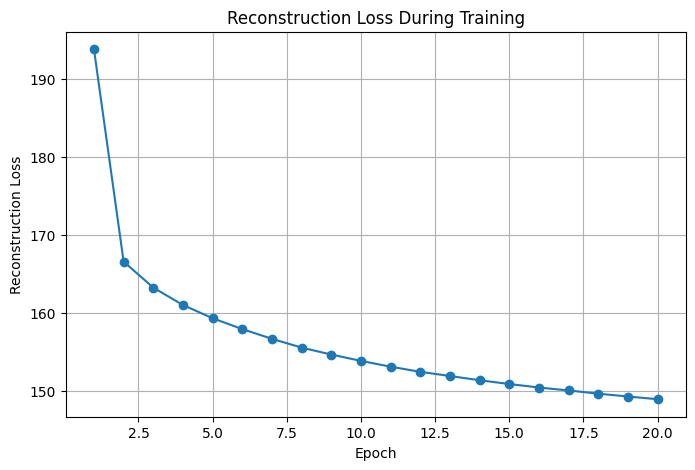

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    reconstruction_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Reconstruction Loss During Training")
plt.grid(True)

plt.show()

## **14. KL-Divergence Loss During Training**

####KL-divergence loss measures how closely the learned latent distribution follows the standard normal distribution.

####The KL loss is an important part of VAE training because it helps create a continuous and structured latent space.

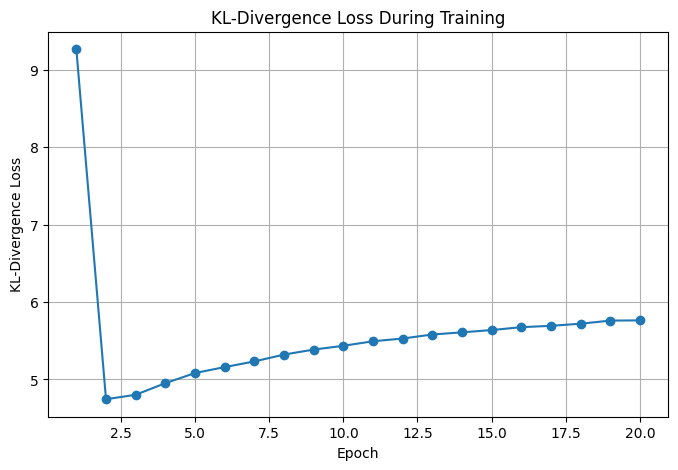

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    kl_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("KL-Divergence Loss")
plt.title("KL-Divergence Loss During Training")
plt.grid(True)

plt.show()

## **15. Total VAE Loss During Training**

The Total VAE Loss is the sum of the reconstruction loss and KL-divergence loss.

It represents the overall objective that the VAE attempts to minimize during
training.

The total loss is monitored across the 20 epochs to understand the overall
training behaviour of the model.

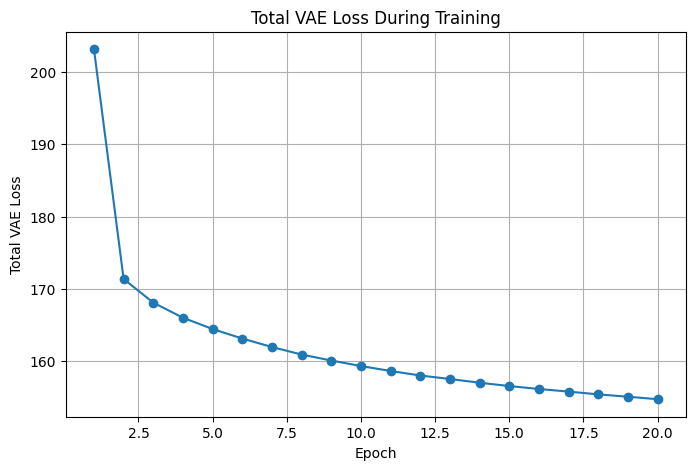

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    total_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Total VAE Loss")
plt.title("Total VAE Loss During Training")
plt.grid(True)

plt.show()

## **16. Reconstruction Loss vs KL-Divergence Loss**

####The following graph compares the two major components of the VAE loss during training.

####The reconstruction loss represents the quality of image reconstruction, while the KL-divergence loss represents the regularisation of the latent distribution.

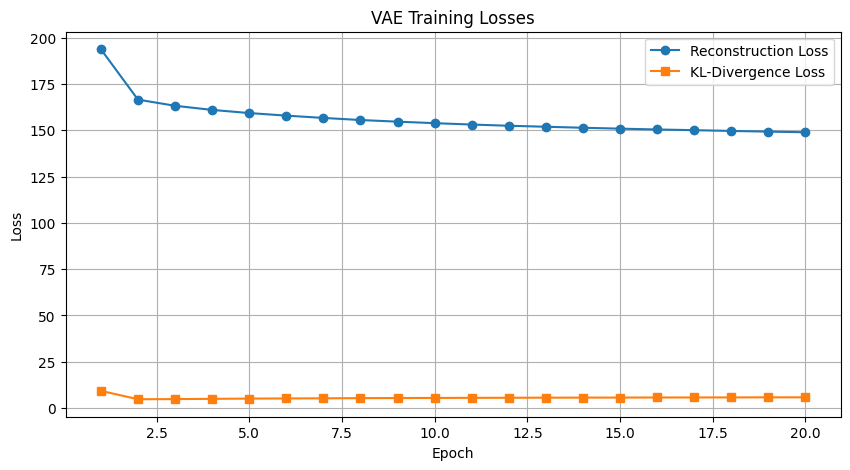

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, epochs + 1),
    reconstruction_losses,
    marker="o",
    label="Reconstruction Loss"
)

plt.plot(
    range(1, epochs + 1),
    kl_losses,
    marker="s",
    label="KL-Divergence Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Losses")
plt.legend()
plt.grid(True)

plt.show()

## **17. Comparison of VAE Losses**

The following graph compares the reconstruction loss, KL-divergence loss, and
total VAE loss across the 20 training epochs.

This comparison helps to understand how the different components contribute to
the overall VAE training process.

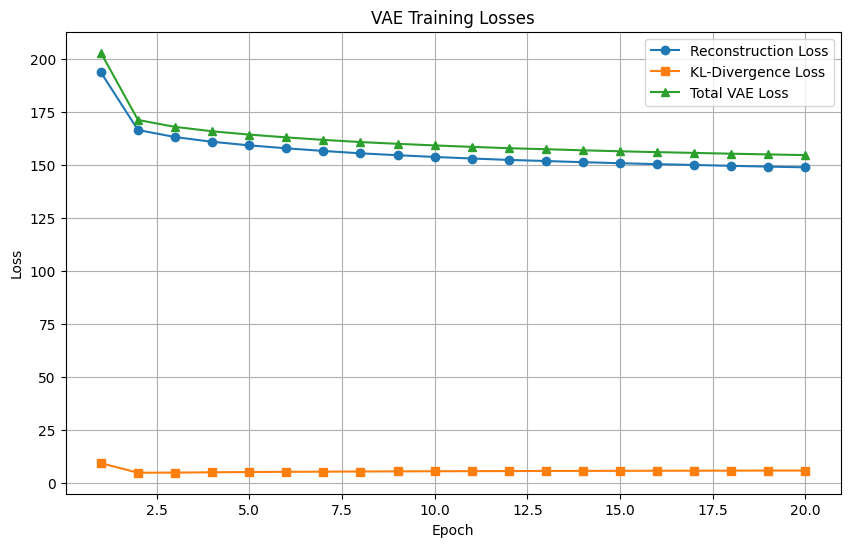

In [25]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, epochs + 1),
    reconstruction_losses,
    marker="o",
    label="Reconstruction Loss"
)

plt.plot(
    range(1, epochs + 1),
    kl_losses,
    marker="s",
    label="KL-Divergence Loss"
)

plt.plot(
    range(1, epochs + 1),
    total_losses,
    marker="^",
    label="Total VAE Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Losses")
plt.legend()
plt.grid(True)

plt.show()

## **18. Visualising the 2D Latent Space**

####After training, the test images are passed through the encoder.

####The encoder produces a mean vector containing two values for every image.

####These two values represent the coordinates of the image in the learned 2D latent space.

####The points are coloured according to their actual digit labels from 0 to 9.

In [ ]:
# Encode test images
z_mean_test, z_log_var_test, z_test = encoder.predict(
    x_test,
    batch_size=256,
    verbose=1
)

print("Latent representation shape:", z_mean_test.shape)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Latent representation shape: (10000, 2)


## **19. 2D Latent Space Scatter Plot**

####The following scatter plot shows the 2-dimensional latent representation learned by the VAE.

####Each point represents one MNIST test image.

####The colour of each point corresponds to its digit label from 0 to 9.

####If similar digits are mapped to nearby locations, clusters of similar colours should appear in the latent space.

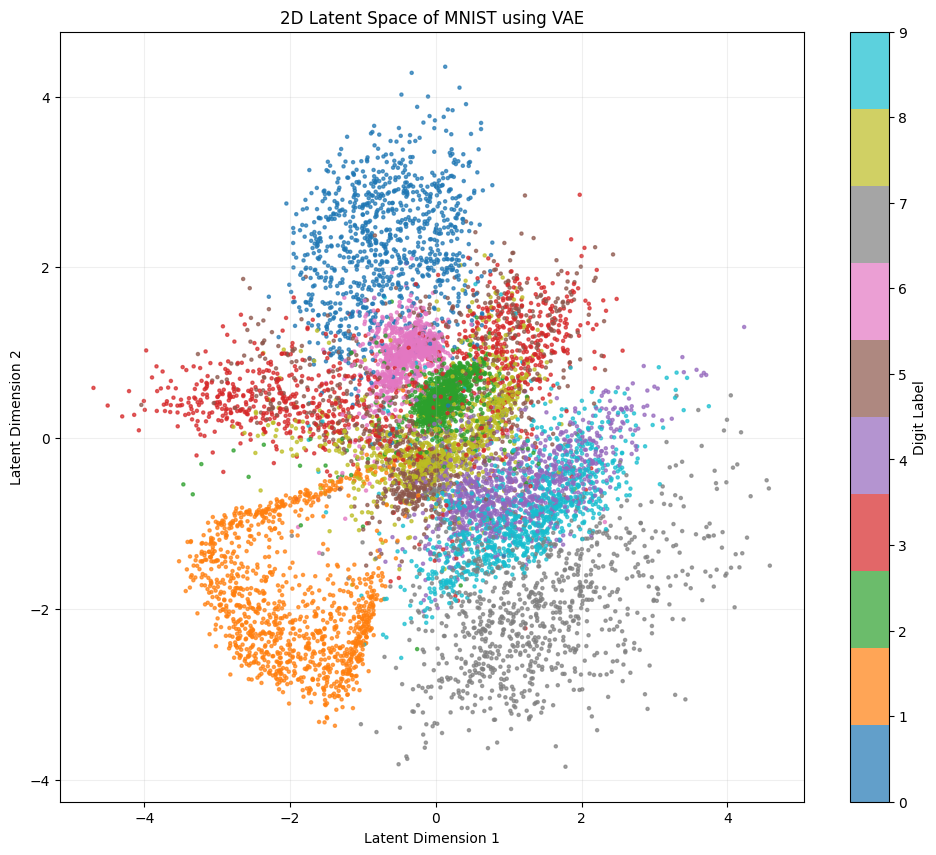

In [ ]:
plt.figure(figsize=(12, 10))

scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=5,
    alpha=0.7
)

plt.colorbar(
    scatter,
    ticks=range(10),
    label="Digit Label"
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("2D Latent Space of MNIST using VAE")
plt.grid(alpha=0.2)

plt.show()

## **20. Reconstruction of Test Images**

####The trained VAE can reconstruct test images by passing them through the encoder and decoder.

####The original and reconstructed images can be compared to understand how well the model has learned the important visual features of handwritten digits.

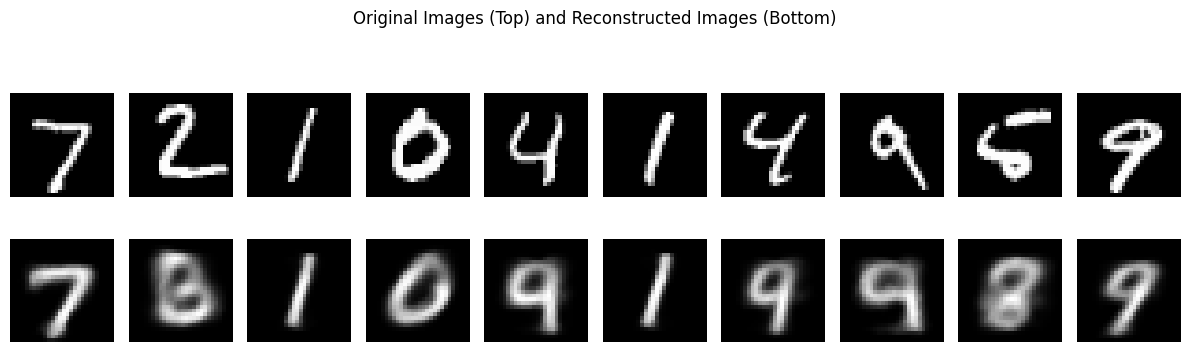

In [ ]:
# Select test images
sample_images = x_test[:10]

# Encode
sample_mean, sample_log_var, sample_z = encoder.predict(
    sample_images,
    verbose=0
)

# Decode
reconstructed_images = decoder.predict(
    sample_z,
    verbose=0
)

plt.figure(figsize=(12, 4))

for i in range(10):
    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(
        sample_images[i].reshape(28, 28),
        cmap="gray"
    )
    plt.axis("off")

    # Reconstruction
    plt.subplot(2, 10, i + 11)
    plt.imshow(
        reconstructed_images[i].reshape(28, 28),
        cmap="gray"
    )
    plt.axis("off")

plt.suptitle(
    "Original Images (Top) and Reconstructed Images (Bottom)"
)

plt.tight_layout()
plt.show()

## **21. Generating Digits by Sampling the Latent Space**

####One important property of a VAE is that it can generate new samples from its latent space.

####A grid of points is selected between approximately -3 and +3 for both latent dimensions.

Each point is passed through the trained decoder.

The resulting output is a generated 28 × 28 MNIST-like digit image.

Moving from one point to another allows us to observe how the generated digit
changes gradually through the latent space.

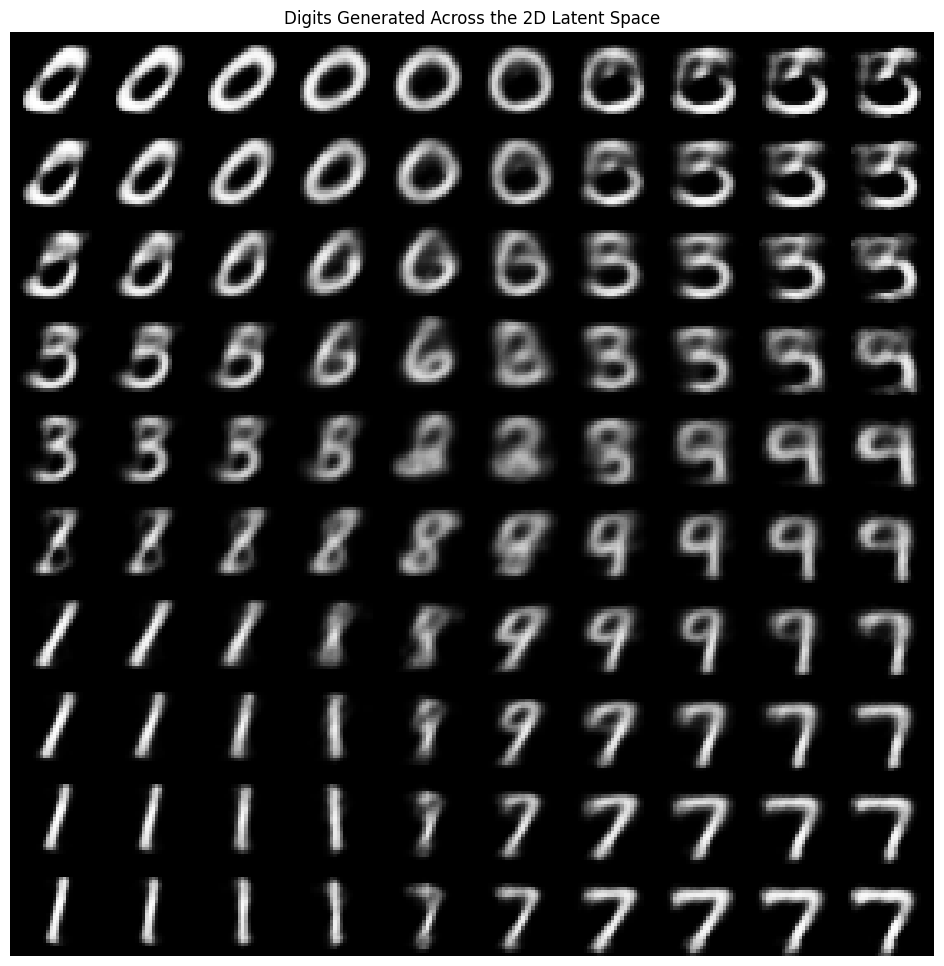

In [19]:
# Define latent space grid
grid_size = 10

z1 = np.linspace(-3, 3, grid_size)
z2 = np.linspace(-3, 3, grid_size)

figure = np.zeros(
    (28 * grid_size, 28 * grid_size)
)

for i, y in enumerate(z2[::-1]):
    for j, x in enumerate(z1):

        latent_vector = np.array(
            [[x, y]],
            dtype=np.float32
        )

        decoded_image = decoder.predict(
            latent_vector,
            verbose=0
        )

        digit = decoded_image[0].reshape(28, 28)

        figure[
            i * 28:(i + 1) * 28,
            j * 28:(j + 1) * 28
        ] = digit

plt.figure(figsize=(12, 12))

plt.imshow(
    figure,
    cmap="gray"
)

plt.title(
    "Digits Generated Across the 2D Latent Space"
)

plt.axis("off")

plt.show()

## **22. Latent Space Generation Grid**

####The generated image grid demonstrates how the decoder maps different latent coordinates into different handwritten digits.

####The horizontal and vertical directions correspond to the two latent dimensions.

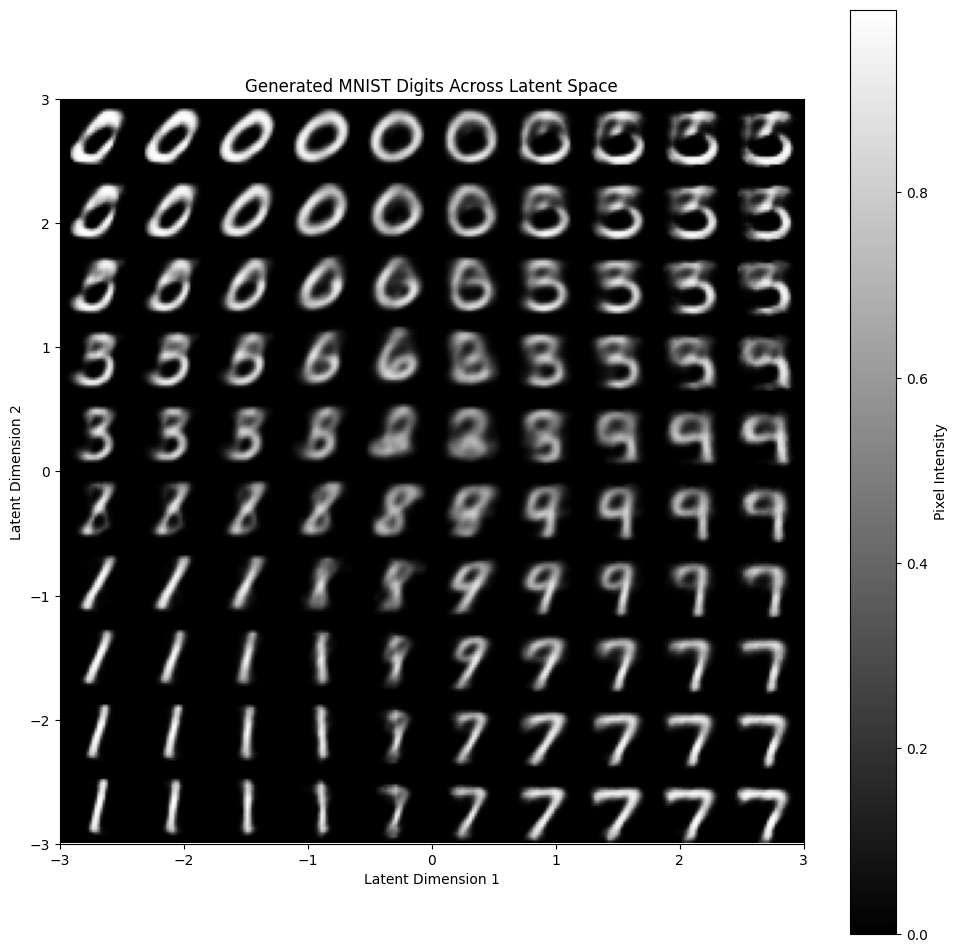

In [20]:
grid_size = 10

figure = np.zeros(
    (28 * grid_size, 28 * grid_size)
)

grid_values = np.linspace(-3, 3, grid_size)

for i, y in enumerate(grid_values[::-1]):
    for j, x in enumerate(grid_values):

        z_sample = np.array(
            [[x, y]],
            dtype=np.float32
        )

        decoded = decoder.predict(
            z_sample,
            verbose=0
        )[0]

        digit = decoded.reshape(28, 28)

        figure[
            i * 28:(i + 1) * 28,
            j * 28:(j + 1) * 28
        ] = digit

plt.figure(figsize=(12, 12))

plt.imshow(
    figure,
    cmap="gray",
    extent=[-3, 3, -3, 3]
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")

plt.title(
    "Generated MNIST Digits Across Latent Space"
)

plt.colorbar(label="Pixel Intensity")

plt.show()

## **23. Interpretation of the Generated Digit Grid**

####The generated grid demonstrates the continuous nature of the VAE latent space.

####Each location in the grid corresponds to a different two-dimensional latent vector.

####The decoder transforms these latent vectors into handwritten digit images.

####As we move gradually across the latent space, the generated digits can change in shape, thickness, orientation, and structure.

####The transition between nearby points is generally smooth because the VAE encourages a continuous and organised latent representation.

## **24. Observations**

### **1. Do similar digits form clusters?**

####Yes. Similar handwritten digits tend to appear relatively close to each other in the 2D latent space. For example, digits with similar shapes may occupy nearby regions.

####However, the clusters are not expected to be perfectly separated because the VAE learns a continuous latent representation rather than explicitly performing classification.

### **2. Are the clusters clearly separated?**

####The clusters show some degree of separation, but complete separation is generally not expected.

###Some digits may overlap because different handwritten digits can have similar visual characteristics. Since the latent space is restricted to only two dimensions, some information is also compressed.

### **3. How do generated digits change when moving gradually through the latent space?**

####The generated digits change gradually as the latent coordinates change.

####For example, a digit may gradually change its stroke thickness, shape, angle, or structure instead of changing completely from one digit to another.

### **4. Does the transition between generated images appear smooth?**

####Generally, yes.

####Nearby points in the latent space tend to produce visually similar images. This demonstrates that the VAE has learned a continuous latent representation.

####The exact quality of the generated digits can vary depending on training time, network architecture, and the learned latent distribution.

## **25. Key Findings**

####The main findings from this experiment are:

- The VAE successfully learns a 2-dimensional latent representation of MNIST.
- Reconstruction loss provides a measure of how accurately the model reconstructs
  the input images.
- KL-divergence regularises the latent distribution.
- The 2D latent space contains regions associated with different handwritten digits.
- Similar digits tend to have nearby latent representations.
- Some overlap between digit classes can be observed.
- The decoder can generate new digit-like images from latent coordinates.
- Moving gradually through the latent space produces gradual changes in the
  generated images.
- The experiment demonstrates how VAEs can learn continuous and structured
representations suitable for generative tasks.

## **26. Conclusion**

####In this assignment, a Variational Autoencoder was successfully implemented using the MNIST handwritten digit dataset.

####The VAE consisted of an encoder, a 2-dimensional latent space, and a decoder. The encoder learned the mean and log variance of the latent distribution, while the decoder reconstructed images from sampled latent vectors.

####The model was trained for 20 epochs while separately recording reconstruction loss and KL-divergence loss.

####The learned latent representations were visualised using a 2D scatter plot. Different digit classes occupied different regions of the latent space, although some overlap was present.

####Finally, points ranging approximately from -3 to +3 were decoded to generate a grid of handwritten digit images. The gradual changes between neighbouring generated images demonstrated the continuous nature of the learned latent space.

#####Therefore, this experiment demonstrates how a Variational Autoencoder can learn a structured and continuous latent representation and use that representation to generate new data.